In [128]:
from numpy import random,zeros,sort
from matplotlib.pyplot import plot,figure,grid,title,xlabel,ylabel,axhline,axvline,scatter,legend
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Importar datos

In [115]:
df = pd.read_csv("Datos_Prueba.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Variable1  2500 non-null   float64
 1   Variable2  2500 non-null   float64
dtypes: float64(2)
memory usage: 39.2 KB


In [116]:
df.head(10)

,Variable1,Variable2
0,4.33,2.36
1,1.45,2.00
2,3.62,1.64
3,3.27,2.05
4,3.00,1.91
5,3.43,2.60
6,2.03,2.51
7,3.23,2.22
8,1.86,2.07
9,4.48,1.46


Graficar los datos

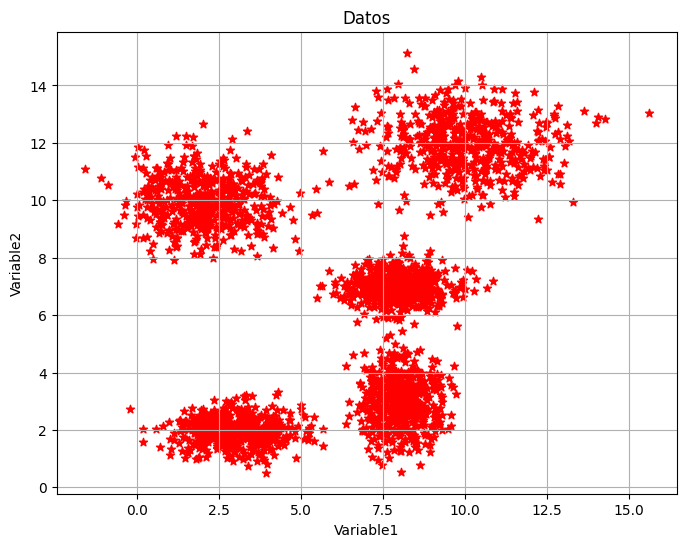

In [117]:
#Número de registros
n = len(df)
figure(figsize = (8,6))
grid()
title("Datos")
xlabel("Variable1")
ylabel("Variable2")
#Graficar los números pseudoaleatorios generados
for i in range(0,n):
    scatter(df["Variable1"][i], df["Variable2"][i], color="red", marker="*")

# Aplicar el algoritmo K-Means

In [118]:
#Definir número de clusters
K = 4
#Aplicar K-Means con un número de clusters específico
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=10, n_init='auto')
clusters = kmeans.fit_predict(df)
#Agregar una columna al dataframe con los grupos asignados
df['Cluster'] = clusters

Graficar datos agrupados

Text(0.5, 1.0, 'Datos agrupados en 4 clusters')

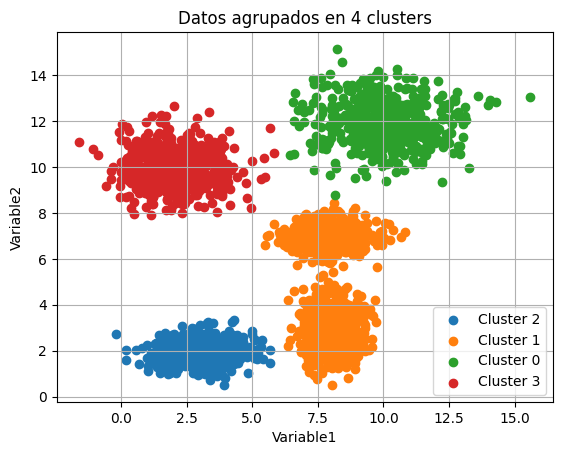

In [119]:
for cluster in df['Cluster'].unique():
    #Filtrar el dataframe según el cluster
    subset = df[df['Cluster'] == cluster]
    scatter(subset['Variable1'], subset['Variable2'], label='Cluster '+str(cluster))

legend()
grid()
xlabel('Variable1')
ylabel('Variable2')
title('Datos agrupados en '+str(K)+" clusters")

# Aplicar el algoritmo K-Means con datos estandarizados

In [120]:
#Definir número de clusters
K = 4
#Estandarizar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

#Aplicar K-Means con un número de clusters específico
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=10, n_init='auto')
clusters = kmeans.fit_predict(df_scaled)
df['Cluster_norm'] = clusters

Graficar datos agrupados

Text(0.5, 1.0, 'Datos agrupados en 4 clusters, aplicando K-Means normalizado')

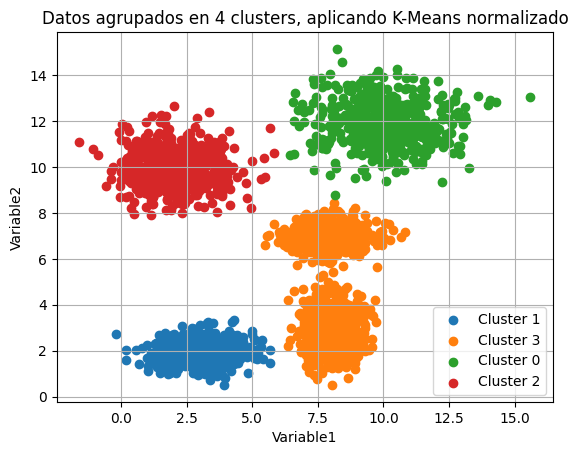

In [121]:
for cluster in df['Cluster_norm'].unique():
    #Filtrar el dataframe según el cluster
    subset = df[df['Cluster_norm'] == cluster]
    scatter(subset['Variable1'], subset['Variable2'], label='Cluster '+str(cluster))

legend()
grid()
xlabel('Variable1')
ylabel('Variable2')
title('Datos agrupados en '+str(K)+" clusters, aplicando K-Means normalizado")

# Detectar número óptimo de clusters

In [122]:
def elbow_method(data, max_clusters=10):
    suma_cuadrados_distancias = []
    for k in range(2, max_clusters+1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=10, n_init='auto')
        kmeans.fit(data)
        suma_cuadrados_distancias.append(kmeans.inertia_) 
    #Graficar la curva del codo
    plot(range(2, max_clusters+1), suma_cuadrados_distancias, 'bx-')
    xlabel('Número de Clusters (k)')
    ylabel('Suma de los Cuadrados de las Distancias')
    title('Curva del Codo')
    grid()
    return

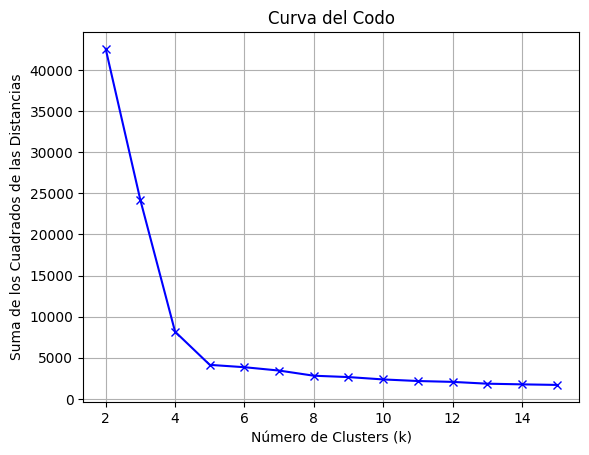

In [123]:
elbow_method(df, 15)

In [124]:
def silueta_indice(data, max_clusters=10):
    indice = []
    for k in range(2, max_clusters+1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=10, n_init='auto')
        etiquetas = kmeans.fit_predict(data)
        #etiquetas = modelo_kmeans.fit_predict(X)
        #Calcular el índice de la silueta
        score = silhouette_score(data, etiquetas)
        indice.append(score)
    #Graficar la curva del codo
    plot(range(2, max_clusters+1), indice, 'bx-')
    xlabel('Número de Clusters (k)')
    ylabel('Score')
    title('Índice de la Silueta')
    grid()
    return

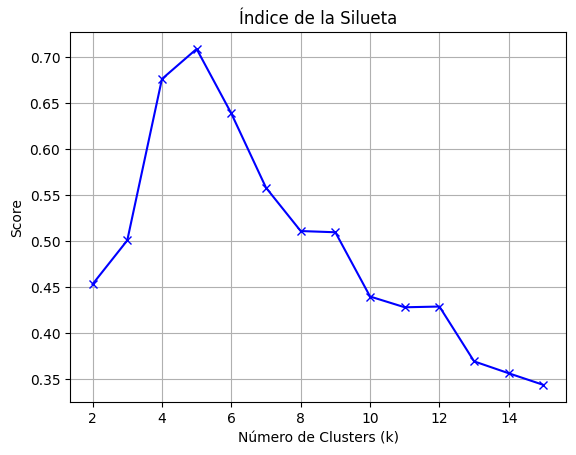

In [125]:
silueta_indice(df, 15)

# Aplicar DBSCAN

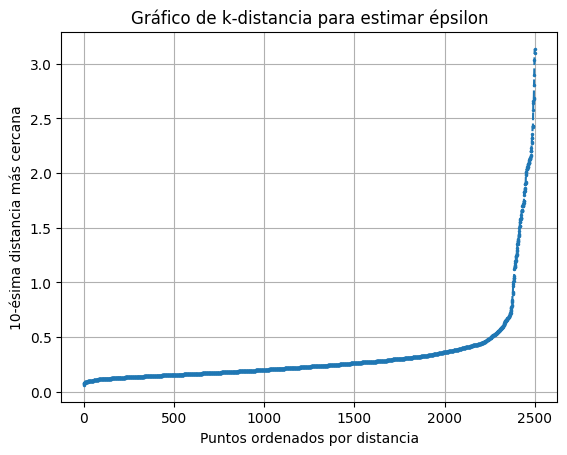

In [132]:
min_pts = 10 
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(df)
distances, indices = neighbors_fit.kneighbors(df)

#Ordenar las distancias y graficar
distances = sort(distances[:, min_pts - 1], axis=0)
plot(distances, linestyle="--", marker="o", markersize=1.5)
title('Gráfico de k-distancia para estimar épsilon')
xlabel('Puntos ordenados por distancia')
ylabel(f'{min_pts}-ésima distancia más cercana')
grid()

Text(0.5, 1.0, 'Clustering aplicando DBSCAN')

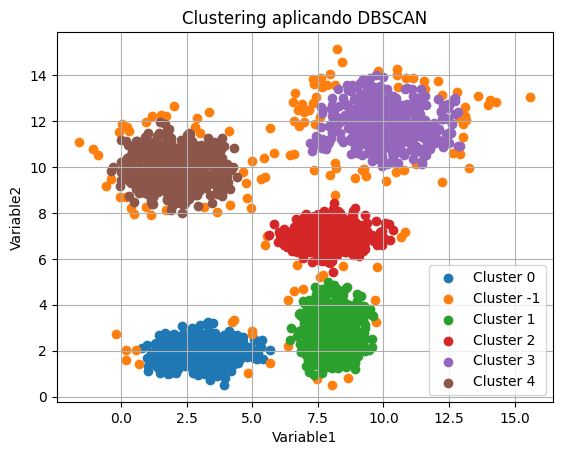

In [133]:
#De acuerdo a la gráfica seleccionamos eps=4.5
dbscan = DBSCAN(eps=0.45, min_samples=min_pts)
df["Cluster_DBSCAN"] = dbscan.fit_predict(df)

for cluster in df['Cluster_DBSCAN'].unique():
    #Filtrar el dataframe según el cluster
    subset = df[df['Cluster_DBSCAN'] == cluster]
    scatter(subset['Variable1'], subset['Variable2'], label='Cluster '+str(cluster))

legend()
grid()
xlabel('Variable1')
ylabel('Variable2')
title('Clustering aplicando DBSCAN')